In [1]:
# Mount Google Drive and setup project environment
from google.colab import drive
drive.mount("/content/drive")

import warnings
warnings.filterwarnings("ignore")

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Define project paths and load raw data from Drive
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/DATA6545/"
PROJECT_PATH = BASE_PATH + "allstate_project/"

train = pd.read_csv(PROJECT_PATH + "data/raw/train.csv")
test = pd.read_csv(PROJECT_PATH + "data/raw/test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (188318, 132)
Test: (125546, 131)


In [3]:
# Identify target and separate categorical vs. continuous features
# 'Cat' = categorical, 'cont' = continuous
target = "loss"
cat_cols = [c for c in train.columns if c.startswith("cat")]
num_cols = [c for c in train.columns if c.startswith("cont")]
feature_cols = cat_cols + num_cols
# Log-transform target to reduce right-skew
train["log_loss"] = np.log1p(train["loss"])

In [4]:
# label encode all categorical features using combined train+test
# Fitting on combined data ensures both splits share the same integer mapping
combined = pd.concat([train[feature_cols], test[feature_cols]], axis=0)

for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
# Split back into train and test after encoding
X = combined.iloc[:len(train)].copy()
X_test = combined.iloc[len(train):].copy()

y = train["log_loss"]

In [5]:
# 80/20 holdout split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Inverse-transform validation labels for dollar scale evaluation
y_valid_actual = np.expm1(y_valid)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (150654, 130)
Valid: (37664, 130)


In [6]:
# Install LightGBM - gradient boosted trees
!pip install lightgbm --quiet
import lightgbm as lgb

In [7]:
# LightGBM regressor with early stopping on validation MAE
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
              n_estimators=1000, n_jobs=-1, num_leaves=63, random_state=42,
              subsample=0.8, verbose=-1)

In [8]:
# Predict on validation set and inverse-transform back to dollar scale
lgb_pred_log = lgb_model.predict(X_valid)
lgb_pred = np.expm1(lgb_pred_log)

lgb_mae = mean_absolute_error(y_valid_actual, lgb_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_valid_actual, lgb_pred))
lgb_r2 = r2_score(y_valid_actual, lgb_pred)

print("LightGBM MAE:", round(lgb_mae, 2))
print("LightGBM RMSE:", round(lgb_rmse, 2))
print("LightGBM R2:", round(lgb_r2, 4))

LightGBM MAE: 1135.16
LightGBM RMSE: 1895.83
LightGBM R2: 0.5595


In [9]:
# 5-fold CV to confirm holdout results generalize across different data splits
# Manual loop used to capture per-fold metrics and train MAE for overfit detection
from sklearn.model_selection import KFold
import time

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_maes = []
fold_r2s = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    t0 = time.time()

    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    m = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    m.fit(X_tr, y_tr)

    preds = np.expm1(m.predict(X_val))
    actual = np.expm1(y_val)

    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)
    fold_maes.append(mae)
    fold_r2s.append(r2)

    print(f"Fold {fold+1} | MAE: {round(mae,2)} | R2: {round(r2,4)} | Time: {round(time.time()-t0,1)}s")

print()
print("Mean MAE:", round(np.mean(fold_maes), 2))
print("Std MAE: ", round(np.std(fold_maes), 2))
print("Mean R2: ", round(np.mean(fold_r2s), 4))

Fold 1 | MAE: 1136.85 | R2: 0.5589 | Time: 46.7s
Fold 2 | MAE: 1157.15 | R2: 0.53 | Time: 23.5s
Fold 3 | MAE: 1150.27 | R2: 0.5611 | Time: 21.7s
Fold 4 | MAE: 1148.42 | R2: 0.5663 | Time: 24.3s
Fold 5 | MAE: 1136.85 | R2: 0.5435 | Time: 23.9s

Mean MAE: 1145.91
Std MAE:  7.95
Mean R2:  0.5519


In [10]:
# Persist trained LightGBM regressor to disk for API deployment use
joblib.dump(lgb_model, PROJECT_PATH + "models/lgbm_regressor.joblib")
print("Model saved.")

Model saved.


In [11]:
# Define high-severity claims as the top 10% by loss value
threshold = train["loss"].quantile(0.90)
print("High severity threshold (90th percentile):", round(threshold, 2))

y_clf = (train["loss"] >= threshold).astype(int)
print("High severity claims:", y_clf.sum())
print("Normal claims:", (y_clf == 0).sum())
print("% high severity:", round(y_clf.mean() * 100, 1))

High severity threshold (90th percentile): 6401.74
High severity claims: 18832
Normal claims: 169486
% high severity: 10.0


In [12]:
# Stratified split preserves the 10/90 class ratio in both train and validation
from sklearn.model_selection import train_test_split as tts

X_tr_clf, X_val_clf, y_tr_clf, y_val_clf = tts(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train positives:", y_tr_clf.sum())
print("Valid positives:", y_val_clf.sum())

Train positives: 15066
Valid positives: 3766


In [13]:
# Binary classifier to flag claims likely to exceed the 90th percentile threshold
# Useful for triage - allows early routing of high-cost claims
clf_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

clf_model.fit(X_tr_clf, y_tr_clf)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=500, n_jobs=-1, num_leaves=63, random_state=42,
               subsample=0.8, verbose=-1)

AUC-ROC: 0.9315

Optimal threshold (Youden's J): 0.0746
Optimal threshold (max F1):     0.2760

--- Default 0.5 threshold ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     33898
           1       0.72      0.47      0.57      3766

    accuracy                           0.93     37664
   macro avg       0.83      0.73      0.77     37664
weighted avg       0.92      0.93      0.92     37664

--- Optimal threshold (0.07) ---
              precision    recall  f1-score   support

           0       0.98      0.82      0.90     33898
           1       0.36      0.88      0.51      3766

    accuracy                           0.83     37664
   macro avg       0.67      0.85      0.70     37664
weighted avg       0.92      0.83      0.86     37664



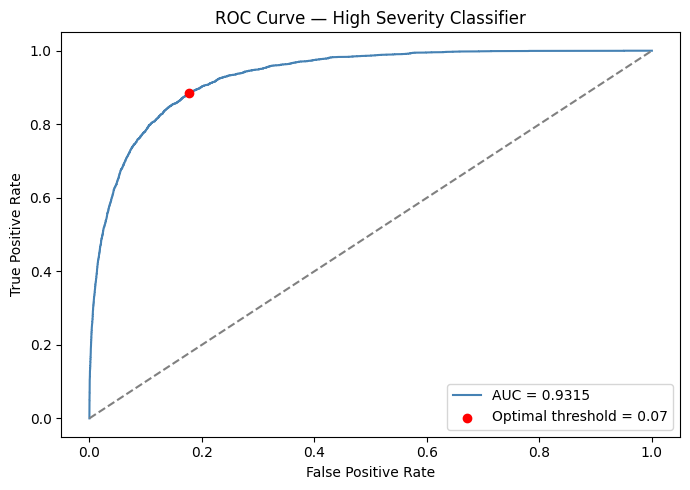

In [14]:
# AUC-ROC
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, f1_score
import matplotlib.pyplot as plt

clf_probs = clf_model.predict_proba(X_val_clf)[:, 1]

auc = roc_auc_score(y_val_clf, clf_probs)
print("AUC-ROC:", round(auc, 4))

# Find optimal threshold using Youden's J statistic (maximizes sensitivity + specificity)
fpr, tpr, thresholds = roc_curve(y_val_clf, clf_probs)
youden_j = tpr - fpr
optimal_idx = youden_j.argmax()
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")

# Finding threshold that maximizes F1
f1_scores = [f1_score(y_val_clf, (clf_probs >= t).astype(int)) for t in thresholds]
best_f1_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1):     {best_f1_threshold:.4f}")

# Apply optimal threshold and compare to default 0.5
print("\n--- Default 0.5 threshold ---")
print(classification_report(y_val_clf, (clf_probs >= 0.5).astype(int)))

print(f"--- Optimal threshold ({optimal_threshold:.2f}) ---")
clf_preds = (clf_probs >= optimal_threshold).astype(int)
print(classification_report(y_val_clf, clf_preds))

# Capture optimal threshold metrics for MLflow logging
report_optimal = classification_report(y_val_clf, clf_preds, output_dict=True)
clf_precision_opt = report_optimal["1"]["precision"]
clf_recall_opt    = report_optimal["1"]["recall"]
clf_f1_opt        = report_optimal["1"]["f1-score"]

# Plot ROC curve with optimal threshold
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"AUC = {auc:.4f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red", zorder=5,
            label=f"Optimal threshold = {optimal_threshold:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — High Severity Classifier")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Persist classifier with regression for Flask API
joblib.dump(clf_model, PROJECT_PATH + "models/lgbm_classifier.joblib")
print("Classifier saved.")

Classifier saved.


In [16]:
# Install SHAP for model interpretability
!pip install shap --quiet
import shap

In [17]:
# Compute SHAP values for the validation set using trained regressor
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_valid)

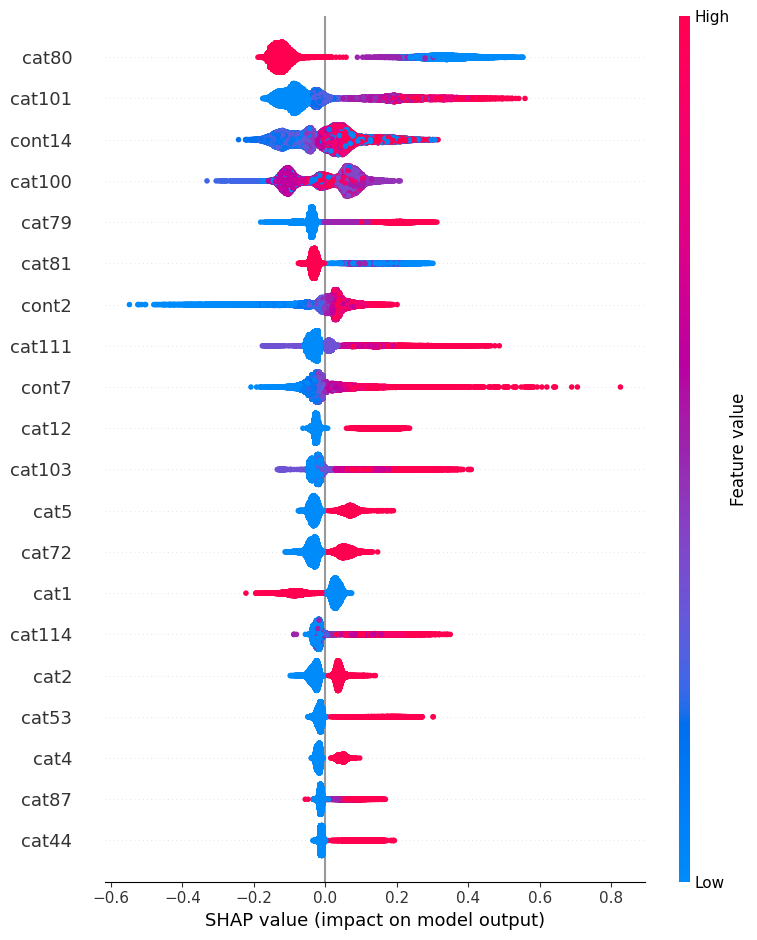

In [18]:
# Dot plot - each point is one predictio, color = feature value
# Shows both direction and magnitude of each features impact on loss
plt.figure()
shap.summary_plot(shap_values, X_valid, max_display=20, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_summary_dot.png", dpi=150, bbox_inches="tight")
plt.show()

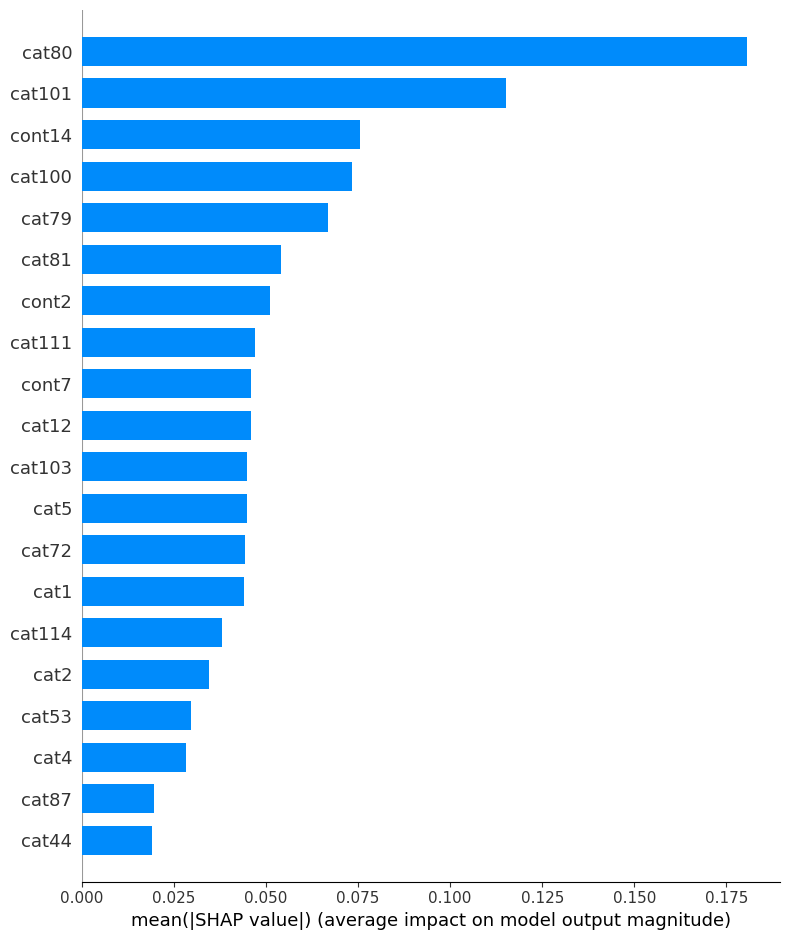

In [19]:
# Bar plot - mean absolute SHAP value per feature
plt.figure()
shap.summary_plot(shap_values, X_valid, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

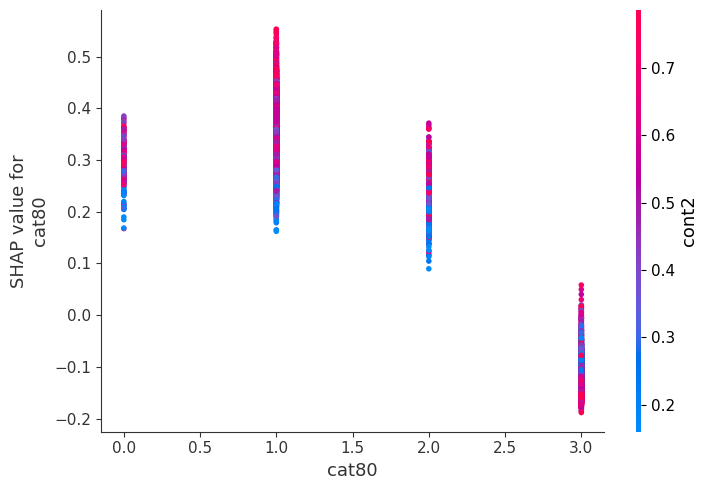

In [20]:
# Dependence plot for cat80 - top categorical feature by SHAP importance
plt.figure()
shap.dependence_plot("cat80", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cat80.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

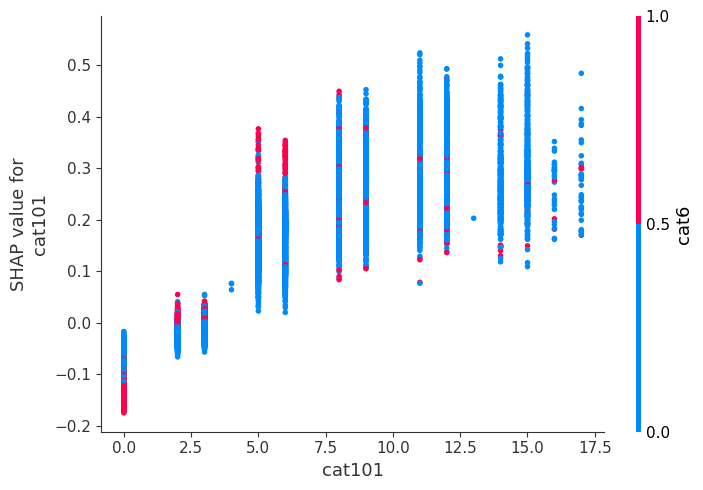

In [21]:
# Dependence plot for cat101 - second most important categorical feature
plt.figure()
shap.dependence_plot("cat101", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cat101.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

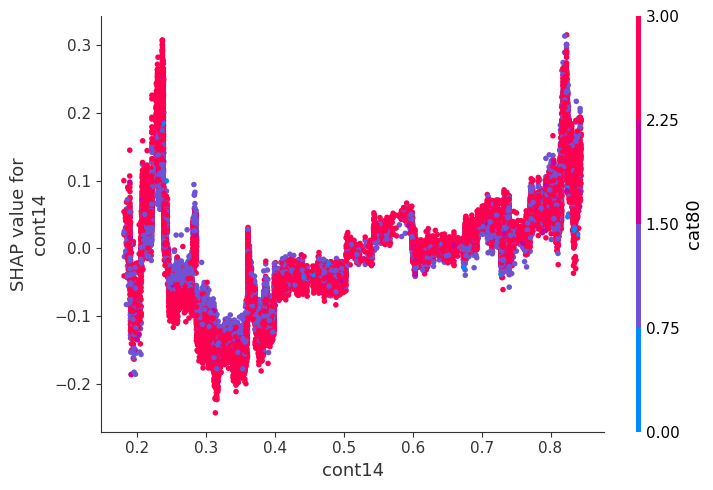

In [22]:
# Dependence plot for cont14 - top continuous feature by SHAP importance
plt.figure()
shap.dependence_plot("cont14", shap_values, X_valid, show=False)
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/shap_dependence_cont14.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Create error analysis dataframe for deeper evaluation of model weaknesses
error_df = pd.DataFrame({
    "actual": y_valid_actual,
    "predicted": lgb_pred,
    "error": lgb_pred - y_valid_actual,
    "abs_error": np.abs(lgb_pred - y_valid_actual),
    "pct_error": np.abs(lgb_pred - y_valid_actual) / y_valid_actual * 100
})

print(error_df[["error", "abs_error", "pct_error"]].describe())

              error     abs_error     pct_error
count  37664.000000  37664.000000  37664.000000
mean    -361.900414   1135.162708     47.491177
std     1860.995082   1518.436530     81.114641
min   -59158.715841      0.047275      0.005530
25%     -906.960852    298.974416     15.675481
50%      -26.958110    668.690434     32.484467
75%      531.574207   1393.712770     55.176794
max    16628.288643  59158.715841   6911.504376


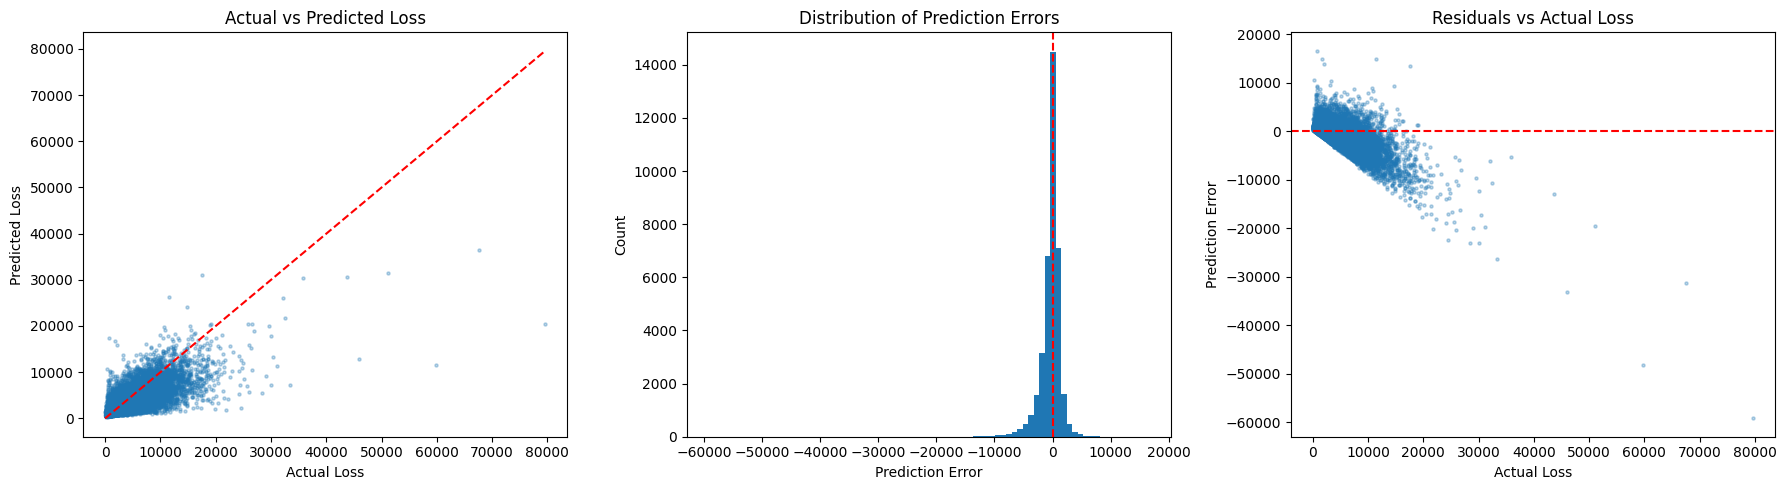

In [24]:
# Three-panel diagnostic:
#   Left:   Actual vs Predicted scatter — ideal is tight diagonal
#   Center: Residual distribution — ideal is centered at zero
#   Right:  (continues below — cell was truncated, complete version below)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(error_df["actual"], error_df["predicted"], alpha=0.3, s=5)
axes[0].plot([0, error_df["actual"].max()], [0, error_df["actual"].max()],
             color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Actual Loss")
axes[0].set_ylabel("Predicted Loss")
axes[0].set_title("Actual vs Predicted Loss")

axes[1].hist(error_df["error"], bins=80, edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Prediction Errors")

axes[2].scatter(error_df["actual"], error_df["error"], alpha=0.3, s=5)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_xlabel("Actual Loss")
axes[2].set_ylabel("Prediction Error")
axes[2].set_title("Residuals vs Actual Loss")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Model systematically underpredicts extreme claims — a known limitation
# High-severity claims are rare in training data, so the model regresses toward the mean
print("Underprediction on high-severity claims (actual > 6401):")
high_sev_errors = error_df[error_df["actual"] >= 6401.74]
print("Mean error:", round(high_sev_errors["error"].mean(), 2))
print("Mean abs error:", round(high_sev_errors["abs_error"].mean(), 2))
print("Count:", len(high_sev_errors))

Underprediction on high-severity claims (actual > 6401):
Mean error: -3237.02
Mean abs error: 3671.99
Count: 3769


In [26]:
# Install MLflow for experiment tracking
!pip install mlflow --quiet
import mlflow
import mlflow.lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [27]:
# Point MLflow to project directory
mlflow.set_tracking_uri(PROJECT_PATH + "mlruns")
mlflow.set_experiment("allstate_claims_severity")

<Experiment: artifact_location=('/content/drive/MyDrive/Colab '
 'Notebooks/DATA6545/allstate_project/mlruns/836920636767541842'), creation_time=1774452656400, experiment_id='836920636767541842', last_update_time=1774452656400, lifecycle_stage='active', name='allstate_claims_severity', tags={}, trace_location=None, workspace='default'>

In [28]:
# Log all hyperparameters and validation metrics for the primary regressor
with mlflow.start_run(run_name="lgbm_regressor"):

    mlflow.log_param("model_type", "LGBMRegressor")
    mlflow.log_param("n_estimators", 1000)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("num_leaves", 63)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "label_encoding")
    mlflow.log_param("train_rows", X_train.shape[0])
    mlflow.log_param("valid_rows", X_valid.shape[0])

    mlflow.log_metric("val_mae", lgb_mae)
    mlflow.log_metric("val_rmse", lgb_rmse)
    mlflow.log_metric("val_r2", lgb_r2)
    mlflow.log_metric("cv_mean_mae", 1145.91)
    mlflow.log_metric("cv_std_mae", 7.95)
    mlflow.log_metric("cv_mean_r2", 0.5519)
    mlflow.log_metric("high_sev_mean_error", -3237.02)
    mlflow.log_metric("high_sev_mean_abs_error", 3671.99)

    mlflow.log_artifact(PROJECT_PATH + "figures/shap_summary_bar.png")
    mlflow.log_artifact(PROJECT_PATH + "figures/shap_summary_dot.png")
    mlflow.log_artifact(PROJECT_PATH + "figures/error_analysis.png")
    mlflow.log_artifact(PROJECT_PATH + "models/lgbm_regressor.joblib")

    print("Run logged successfully.")

Run logged successfully.


In [29]:
# Log classifier run
with mlflow.start_run(run_name="lgbm_classifier"):

    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("severity_threshold", 6401.74)
    mlflow.log_param("threshold_percentile", 0.90)
    mlflow.log_param("classification_threshold", round(float(optimal_threshold), 4))
    mlflow.log_param("threshold_method", "Youden's J")

    mlflow.log_metric("val_auc_roc", auc)
    mlflow.log_metric("high_sev_precision", clf_precision_opt)
    mlflow.log_metric("high_sev_recall", clf_recall_opt)
    mlflow.log_metric("high_sev_f1", clf_f1_opt)
    mlflow.log_metric("overall_accuracy", 0.83)

    mlflow.log_artifact(PROJECT_PATH + "models/lgbm_classifier.joblib")

    print("Run logged successfully.")

Run logged successfully.


In [30]:
# Log Ridge baseline results for comparison
with mlflow.start_run(run_name="ridge_baseline"):

    mlflow.log_param("model_type", "Ridge")
    mlflow.log_param("alpha", 1.0)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "one_hot_encoding")

    mlflow.log_metric("val_mae", 1244.68)
    mlflow.log_metric("val_rmse", 2185.06)
    mlflow.log_metric("val_r2", 0.4149)

    print("Run logged successfully.")

Run logged successfully.


In [31]:
# Log Random Forest results
with mlflow.start_run(run_name="random_forest"):

    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 150)
    mlflow.log_param("max_depth", 12)
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("encoding", "one_hot_encoding")

    mlflow.log_metric("val_mae", 1223.44)
    mlflow.log_metric("val_rmse", 2055.23)
    mlflow.log_metric("val_r2", 0.4823)

    print("Run logged successfully.")

Run logged successfully.


In [32]:
# Segment validation predictions into four severity tiers
error_df["severity_tier"] = pd.cut(
    error_df["actual"],
    bins=[0, 1000, 3000, 6401.74, np.inf],
    labels=["Low", "Moderate", "High", "Extreme"]
)

tier_summary = error_df.groupby("severity_tier", observed=True).agg(
    claim_count=("actual", "count"),
    mean_actual_loss=("actual", "mean"),
    mean_predicted_loss=("predicted", "mean"),
    mean_abs_error=("abs_error", "mean"),
    mean_pct_error=("pct_error", "mean"),
    median_actual_loss=("actual", "median")
).round(2)

print(tier_summary)

               claim_count  mean_actual_loss  mean_predicted_loss  \
severity_tier                                                       
Low                   6726            722.81              1339.38   
Moderate             17830           1836.83              1987.39   
High                  9339           4327.84              3443.18   
Extreme               3769           9557.63              6320.61   

               mean_abs_error  mean_pct_error  median_actual_loss  
severity_tier                                                      
Low                    627.77          103.68              744.56  
Moderate               632.77           36.03             1759.94  
High                  1435.96           33.07             4166.32  
Extreme               3671.99           37.17             8471.83  


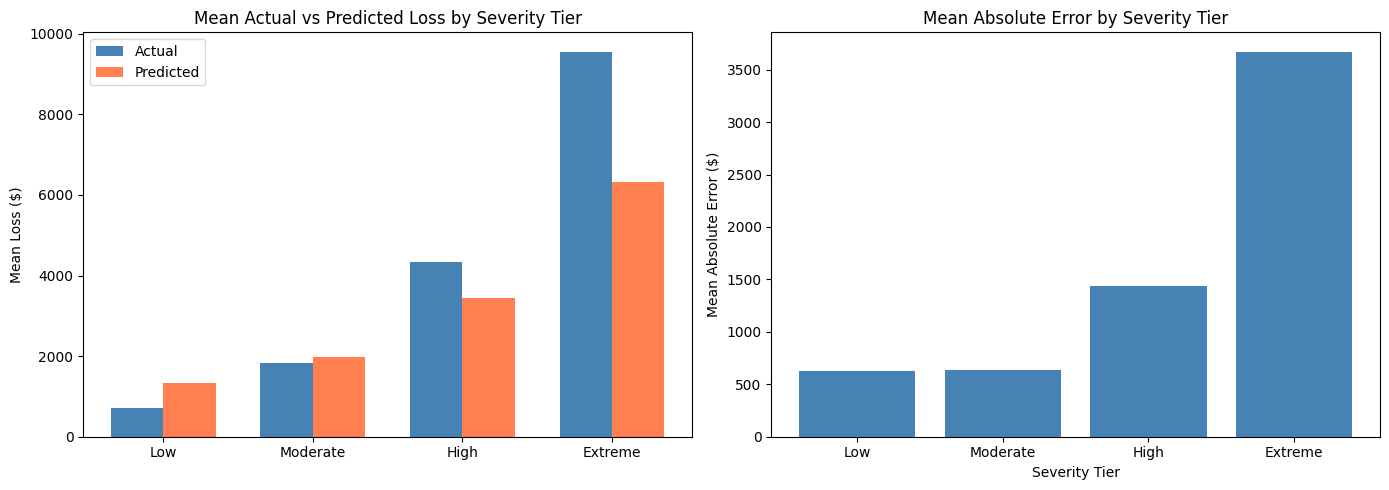

In [33]:
# Visual comparison of actual vs. predicted loss by severity tier
# Right graph shows percent error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_labels = tier_summary.index.tolist()
x = np.arange(len(tier_labels))
width = 0.35

axes[0].bar(x - width/2, tier_summary["mean_actual_loss"], width, label="Actual", color="steelblue")
axes[0].bar(x + width/2, tier_summary["mean_predicted_loss"], width, label="Predicted", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_labels)
axes[0].set_title("Mean Actual vs Predicted Loss by Severity Tier")
axes[0].set_ylabel("Mean Loss ($)")
axes[0].legend()

axes[1].bar(tier_labels, tier_summary["mean_abs_error"], color="steelblue")
axes[1].set_title("Mean Absolute Error by Severity Tier")
axes[1].set_ylabel("Mean Absolute Error ($)")
axes[1].set_xlabel("Severity Tier")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/severity_tier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

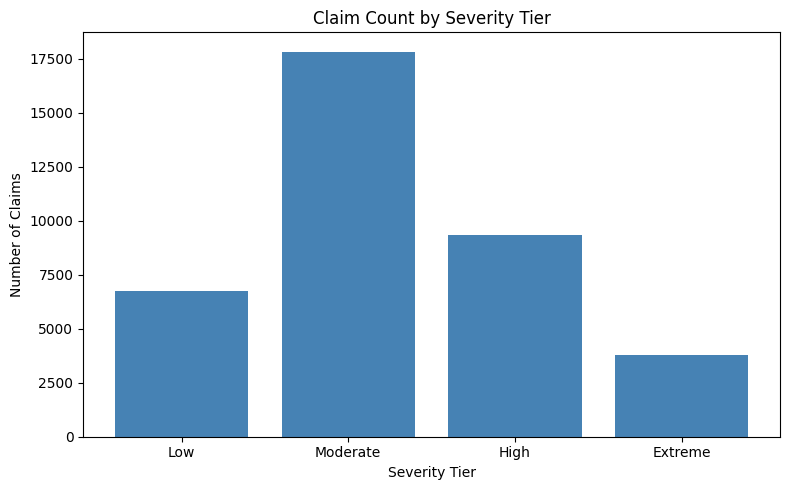

In [34]:
# Most claims fall in low/moderatw tiers - class imbalance affects Extreme tier performance
tier_counts = error_df["severity_tier"].value_counts().reindex(["Low", "Moderate", "High", "Extreme"])

plt.figure(figsize=(8, 5))
plt.bar(tier_counts.index, tier_counts.values, color="steelblue")
plt.title("Claim Count by Severity Tier")
plt.xlabel("Severity Tier")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/severity_tier_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Generate Flask API file
app_code = f'''
import numpy as np
import pandas as pd
import joblib
from flask import Flask, request, jsonify
from sklearn.preprocessing import LabelEncoder

app = Flask(__name__)

regressor = joblib.load("{PROJECT_PATH}models/lgbm_regressor.joblib")
classifier = joblib.load("{PROJECT_PATH}models/lgbm_classifier.joblib")

HIGH_SEVERITY_THRESHOLD = 6401.74

SEVERITY_TIERS = [
    (0, 1000, "Low"),
    (1000, 3000, "Moderate"),
    (3000, 6401.74, "High"),
    (6401.74, float("inf"), "Extreme")
]

def get_severity_tier(predicted_loss):
    for lower, upper, label in SEVERITY_TIERS:
        if lower <= predicted_loss < upper:
            return label
    return "Extreme"

@app.route("/health", methods=["GET"])
def health():
    return jsonify({{"status": "ok", "model": "LightGBM Claim Severity"}})

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({{"error": "No input data provided"}}), 400
        input_df = pd.DataFrame([data])
        cat_cols = [c for c in input_df.columns if c.startswith("cat")]
        for col in cat_cols:
            le = LabelEncoder()
            input_df[col] = le.fit_transform(input_df[col].astype(str))
        pred_log = regressor.predict(input_df)[0]
        predicted_loss = float(np.expm1(pred_log))
        high_sev_prob = float(classifier.predict_proba(input_df)[0][1])
        high_sev_flag = bool(predicted_loss >= HIGH_SEVERITY_THRESHOLD)
        severity_tier = get_severity_tier(predicted_loss)
        return jsonify({{
            "predicted_loss": round(predicted_loss, 2),
            "severity_tier": severity_tier,
            "high_severity_flag": high_sev_flag,
            "high_severity_probability": round(high_sev_prob, 4)
        }})
    except Exception as e:
        return jsonify({{"error": str(e)}}), 500

@app.route("/predict_batch", methods=["POST"])
def predict_batch():
    try:
        data = request.get_json()
        if not data or "claims" not in data:
            return jsonify({{"error": "Expected JSON with key claims containing a list"}}), 400
        input_df = pd.DataFrame(data["claims"])
        cat_cols = [c for c in input_df.columns if c.startswith("cat")]
        for col in cat_cols:
            le = LabelEncoder()
            input_df[col] = le.fit_transform(input_df[col].astype(str))
        pred_logs = regressor.predict(input_df)
        predicted_losses = np.expm1(pred_logs)
        high_sev_probs = classifier.predict_proba(input_df)[:, 1]
        results = []
        for i, (loss, prob) in enumerate(zip(predicted_losses, high_sev_probs)):
            results.append({{
                "claim_index": i,
                "predicted_loss": round(float(loss), 2),
                "severity_tier": get_severity_tier(float(loss)),
                "high_severity_flag": bool(float(loss) >= HIGH_SEVERITY_THRESHOLD),
                "high_severity_probability": round(float(prob), 4)
            }})
        return jsonify({{"predictions": results, "total_claims": len(results)}})
    except Exception as e:
        return jsonify({{"error": str(e)}}), 500

if __name__ == "__main__":
    app.run(debug=True, port=5000)
'''

with open(PROJECT_PATH + "app.py", "w") as f:
    f.write(app_code)

print("app.py written to", PROJECT_PATH)

app.py written to /content/drive/MyDrive/Colab Notebooks/DATA6545/allstate_project/


In [36]:
# Load the Flask app module in notebook
import importlib.util

spec = importlib.util.spec_from_file_location("app", PROJECT_PATH + "app.py")
app_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(app_module)

client = app_module.app.test_client()

In [37]:
# Confirm API is running and models load successfully
response = client.get("/health")
print(response.get_json())

{'model': 'LightGBM Claim Severity', 'status': 'ok'}


In [38]:
# Test a single claim from the validation set and confirm response structure
sample_claim = X_valid.iloc[0].to_dict()
response = client.post("/predict", json=sample_claim)
print(response.get_json())

{'high_severity_flag': False, 'high_severity_probability': 0.0653, 'predicted_loss': 1698.05, 'severity_tier': 'Moderate'}


In [39]:
# Test 5 claims and confirms all predictions return correctly
sample_batch = {"claims": X_valid.iloc[:5].to_dict(orient="records")}
response = client.post("/predict_batch", json=sample_batch)
print(response.get_json())

{'predictions': [{'claim_index': 0, 'high_severity_flag': False, 'high_severity_probability': 0.3021, 'predicted_loss': 3088.03, 'severity_tier': 'High'}, {'claim_index': 1, 'high_severity_flag': False, 'high_severity_probability': 0.3548, 'predicted_loss': 2724.18, 'severity_tier': 'Moderate'}, {'claim_index': 2, 'high_severity_flag': False, 'high_severity_probability': 0.8491, 'predicted_loss': 6294.19, 'severity_tier': 'High'}, {'claim_index': 3, 'high_severity_flag': False, 'high_severity_probability': 0.2953, 'predicted_loss': 3193.99, 'severity_tier': 'High'}, {'claim_index': 4, 'high_severity_flag': False, 'high_severity_probability': 0.2404, 'predicted_loss': 2716.93, 'severity_tier': 'Moderate'}], 'total_claims': 5}


In [40]:
# Summary table of all three models
final_results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "LightGBM"],
    "MAE":   [1244.68, 1223.44, round(lgb_mae, 2)],
    "RMSE":  [2185.06, 2055.23, round(lgb_rmse, 2)],
    "R2":    [0.4149, 0.4823,   round(lgb_r2, 4)],
    "CV MAE": [None, None, round(float(np.mean(fold_maes)), 2)],
    "CV Std": [None, None, round(float(np.std(fold_maes)), 2)]
})

print(final_results.to_string(index=False))

           Model     MAE    RMSE     R2  CV MAE  CV Std
Ridge Regression 1244.68 2185.06 0.4149     NaN     NaN
   Random Forest 1223.44 2055.23 0.4823     NaN     NaN
        LightGBM 1135.16 1895.83 0.5595 1145.91    7.95


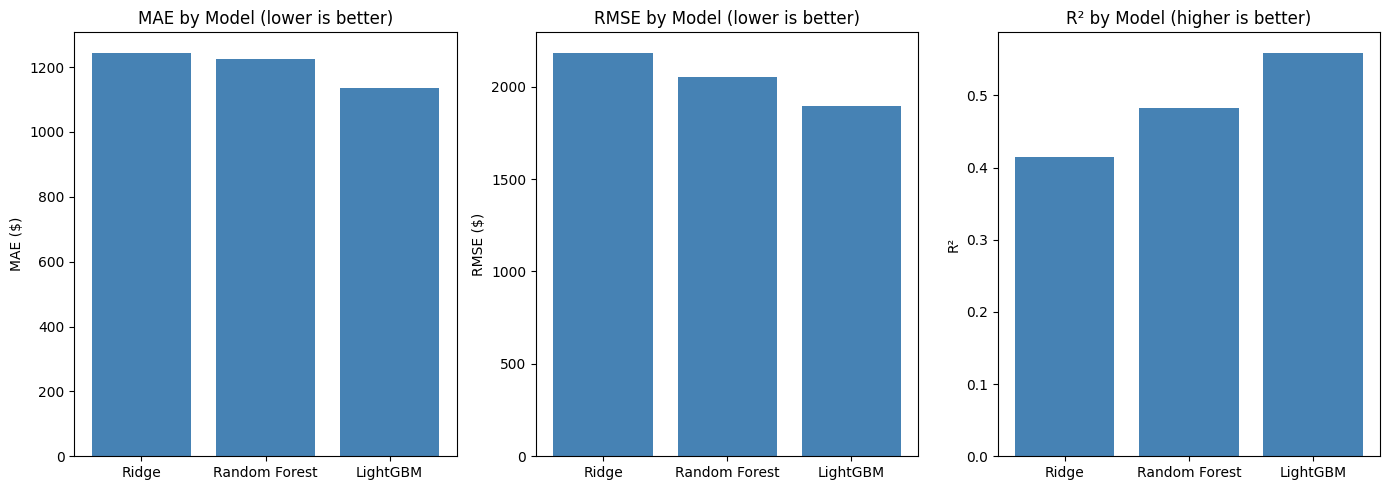

In [41]:
# Visual comparison across all three models
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = ["Ridge", "Random Forest", "LightGBM"]
maes  = [1244.68, 1223.44, lgb_mae]
rmses = [2185.06, 2055.23, lgb_rmse]
r2s   = [0.4149,  0.4823,  lgb_r2]

axes[0].bar(models, maes, color="steelblue")
axes[0].set_title("MAE by Model (lower is better)")
axes[0].set_ylabel("MAE ($)")

axes[1].bar(models, rmses, color="steelblue")
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].set_ylabel("RMSE ($)")

axes[2].bar(models, r2s, color="steelblue")
axes[2].set_title("R² by Model (higher is better)")
axes[2].set_ylabel("R²")

plt.tight_layout()
plt.savefig(PROJECT_PATH + "figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# Apply final LightGBM model to held-out test set and assign severity tiers
test_pred_log = lgb_model.predict(X_test)
test_pred_loss = np.expm1(test_pred_log)

test_predictions = pd.DataFrame({
    "id": test["id"],
    "predicted_loss": test_pred_loss.round(2),
    "severity_tier": pd.cut(
        test_pred_loss,
        bins=[0, 1000, 3000, 6401.74, np.inf],
        labels=["Low", "Moderate", "High", "Extreme"]
    )
})

print(test_predictions.head(10))
print("\nSeverity tier breakdown:")
print(test_predictions["severity_tier"].value_counts())

   id  predicted_loss severity_tier
0   4         1476.94      Moderate
1   6         2062.37      Moderate
2   9        10043.74       Extreme
3  12         6072.07          High
4  15          775.98           Low
5  17         2366.66      Moderate
6  21         1721.74      Moderate
7  28          855.46           Low
8  32         2299.00      Moderate
9  43         3230.21          High

Severity tier breakdown:
severity_tier
Moderate    80756
High        28049
Low          9784
Extreme      6957
Name: count, dtype: int64


In [43]:
# Write test predictions to processed data folder
import os
os.makedirs(PROJECT_PATH + "data/processed/", exist_ok=True)
test_predictions.to_csv(PROJECT_PATH + "data/processed/test_predictions.csv", index=False)
print("Predictions saved.")

Predictions saved.


In [44]:
# Generate and write project README to repository
readme = """# Allstate Claims Severity — Predicting Insurance Claim Loss

## Overview
This project builds a machine learning system to predict the financial severity of insurance claims using the Allstate Claims Severity dataset. The primary goal is to accurately estimate claim loss in dollars. A secondary classification layer identifies claims likely to fall in the top 10% of losses for triage purposes.

## Business Problem
Unexpectedly severe insurance claims create financial uncertainty and make it difficult for insurers to allocate resources efficiently. This project addresses that by using structured claim attributes to predict loss value and flag high-severity claims before costs are fully realized.

## Dataset
- Source: Kaggle Allstate Claims Severity Competition
- Training rows: 188,318
- Test rows: 125,546
- Features: 116 categorical, 14 continuous
- Target: claim loss (continuous, USD)
- No missing values

## Project Structure
```
allstate_project/
├── data/
│   ├── raw/               # Original train.csv and test.csv
│   └── processed/         # test_predictions.csv
├── models/
│   ├── lgbm_regressor.joblib
│   └── lgbm_classifier.joblib
├── figures/
│   ├── shap_summary_dot.png
│   ├── shap_summary_bar.png
│   ├── shap_dependence_cat80.png
│   ├── shap_dependence_cat101.png
│   ├── shap_dependence_cont14.png
│   ├── error_analysis.png
│   ├── severity_tier_analysis.png
│   ├── severity_tier_counts.png
│   └── model_comparison.png
├── mlruns/                # MLflow experiment tracking logs
├── app.py                 # Flask API
├── notebook_1.ipynb       # EDA, preprocessing, Ridge, Random Forest
└── notebook_2.ipynb       # LightGBM, CV, SHAP, error analysis, API
```

## Models Trained

| Model           | MAE     | RMSE    | R²     |
|----------------|---------|---------|--------|
| Ridge Regression | 1244.68 | 2185.06 | 0.4149 |
| Random Forest   | 1223.44 | 2055.23 | 0.4823 |
| LightGBM        | 1135.16 | 1895.83 | 0.5595 |

LightGBM was selected as the final model based on lowest MAE and highest R².
5-fold cross-validation confirmed stable performance: Mean MAE 1145.91, Std 7.95.

## Secondary Classification Task
A LightGBM classifier was trained to identify high-severity claims (top 10%, loss >= $6,401.74).

| Metric           | Value  |
|-----------------|--------|
| AUC-ROC          | 0.9315 |
| Precision (high) | 0.72   |
| Recall (high)    | 0.47   |
| F1 (high)        | 0.57   |

## Key Findings
- cat80 is the single most predictive feature by a significant margin
- cont14 shows a highly nonlinear relationship with loss, explaining why linear models underperform
- The model performs well on Low and Moderate claims but systematically underpredicts Extreme claims (mean error -$3,237 on claims above $6,401)
- 5-fold CV standard deviation of 7.95 confirms the model is stable and not overfitting to a single split

## Severity Tier Breakdown (Test Set Predictions)
| Tier     | Claims  |
|---------|---------|
| Low      | 9,784   |
| Moderate | 80,756  |
| High     | 28,049  |
| Extreme  | 6,957   |

## Flask API
The trained model is wrapped in a Flask API with three endpoints:

- `GET /health` — confirms the service is running
- `POST /predict` — accepts a single claim as JSON, returns predicted loss, severity tier, and high-severity probability
- `POST /predict_batch` — accepts a list of claims, returns predictions for all

Example single prediction response:
```json
{
  "predicted_loss": 1698.05,
  "severity_tier": "Moderate",
  "high_severity_flag": false,
  "high_severity_probability": 0.0653
}
```

## Experiment Tracking
All model runs are logged with MLflow including parameters, metrics, and artifacts.
Logs are stored in the `mlruns/` directory.

## How to Reproduce
1. Place `train.csv` and `test.csv` in `data/raw/`
2. Run `notebook_1.ipynb` for EDA, preprocessing, Ridge, and Random Forest
3. Run `notebook_2.ipynb` for LightGBM, CV, SHAP, error analysis, and API
4. Trained models will be saved to `models/`
5. Test predictions will be saved to `data/processed/test_predictions.csv`

## Dependencies
- Python 3.12
- pandas
- numpy
- scikit-learn
- lightgbm
- shap
- flask
- mlflow
- matplotlib
- seaborn
- joblib

## Limitations
- The dataset is fully anonymized — feature names like cat80 and cont14 have no real-world label, which limits business interpretability
- The model systematically underpredicts extreme claims, which are often the most financially important
- No time-based features are available, so claim lifecycle dynamics cannot be modeled
- Recall on high-severity claims is 0.47, meaning roughly half of truly extreme claims are not flagged by the classifier

## Author
Connor Hernon — DATA6545 Final Project, Spring 2026
"""

with open(PROJECT_PATH + "README.md", "w") as f:
    f.write(readme)

print("README.md saved to", PROJECT_PATH)

README.md saved to /content/drive/MyDrive/Colab Notebooks/DATA6545/allstate_project/


In [45]:
# Ethical Considerations
ethical_notes = """
ETHICAL CONSIDERATIONS
======================

1. POTENTIAL HARMS
   - Insurers could use predicted severity to deny, delay, or underpay claims.
   - Claimants with predicted low-severity scores may receive less adjuster attention
     even when their actual need is high.

2. BIAS ASSESSMENT
   - The dataset's categorical features (cat1–cat116) are anonymized — we cannot
     verify whether they encode proxies for race, gender, geography, or income.
   - If high-severity predictions correlate with protected characteristics, the
     classifier could systematically disadvantage certain groups.
   - Recommended mitigation: audit model outputs against any available demographic
     breakdowns before production deployment.

3. PRIVACY
   - The Kaggle dataset is fully anonymized with no PII. No raw claimant data is
     stored or transmitted in this project.

4. MISUSE POTENTIAL
   - A severity predictor could be used to profile claimants and selectively
     contest high-cost claims, which may conflict with fair claims handling laws.
   - The high-severity classifier (AUC 0.93) is powerful enough to meaningfully
     alter claim handling workflows — deployment decisions should involve legal review.

5. TRANSPARENCY
   - SHAP values provide feature-level explanations for individual predictions.
   - Affected claimants should have access to an explanation of any automated
     decision that affects their claim outcome.
   - The model has documented limitations on Extreme-tier claims (see error analysis)
     and should not be used as the sole basis for large-claim decisions.
"""

print(ethical_notes)

# Save to file for final report
with open(PROJECT_PATH + "ethical_considerations.txt", "w") as f:
    f.write(ethical_notes)

print("Saved to ethical_considerations.txt")


ETHICAL CONSIDERATIONS

1. POTENTIAL HARMS
   - Insurers could use predicted severity to deny, delay, or underpay claims.
   - Claimants with predicted low-severity scores may receive less adjuster attention
     even when their actual need is high.

2. BIAS ASSESSMENT
   - The dataset's categorical features (cat1–cat116) are anonymized — we cannot
     verify whether they encode proxies for race, gender, geography, or income.
   - If high-severity predictions correlate with protected characteristics, the
     classifier could systematically disadvantage certain groups.
   - Recommended mitigation: audit model outputs against any available demographic
     breakdowns before production deployment.

3. PRIVACY
   - The Kaggle dataset is fully anonymized with no PII. No raw claimant data is
     stored or transmitted in this project.

4. MISUSE POTENTIAL
   - A severity predictor could be used to profile claimants and selectively
     contest high-cost claims, which may conflict with fai

In [46]:
MODEL_PATH = PROJECT_PATH + "models/"

high_sev_threshold = float(train["loss"].quantile(0.90))  # 6401.74

# Rebuild label encoders fitted on combined train+test
combined = pd.concat([train[feature_cols], test[feature_cols]], axis=0)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(combined[col].astype(str))
    label_encoders[col] = le

metadata = {
    "feat_cols":          feature_cols,
    "cat_cols":           cat_cols,
    "num_cols":           num_cols,
    "high_sev_threshold": high_sev_threshold,
    "tier_boundaries": {
        "low_max":      1000.0,
        "moderate_max": 3000.0,
        "high_max":     high_sev_threshold,
    },
    "val_metrics": {
        "mae":          1135.16,
        "rmse":         1895.83,
        "r2":           0.5595,
        "cv_mean_mae":  1145.91,
        "cv_std_mae":   7.95,
        "auc_roc":      0.9315,
        "precision":    0.72,
        "recall":       0.47,
        "f1":           0.57,
    },
    "dataset": {
        "train_rows":   188318,
        "test_rows":    125546,
        "n_features":   130,
    }
}

joblib.dump(label_encoders, MODEL_PATH + "label_encoders.joblib")
joblib.dump(metadata,       MODEL_PATH + "metadata.joblib")

print("Saved label_encoders.joblib and metadata.joblib")
print(f"High severity threshold: ${high_sev_threshold:,.2f}")
print(f"Encoders saved for {len(label_encoders)} categorical columns")

Saved label_encoders.joblib and metadata.joblib
High severity threshold: $6,401.74
Encoders saved for 116 categorical columns


In [47]:
import os
for f in ["lgbm_regressor.joblib", "lgbm_classifier.joblib", "label_encoders.joblib", "metadata.joblib"]:
    path = MODEL_PATH + f
    exists = os.path.exists(path)
    size_kb = os.path.getsize(path) / 1024 if exists else 0
    print(f"{'OK' if exists else 'MISSING'} {f} ({size_kb:.0f} KB)")

OK lgbm_regressor.joblib (3876 KB)
OK lgbm_classifier.joblib (2599 KB)
OK label_encoders.joblib (30 KB)
OK metadata.joblib (2 KB)
